# FMATCH/Scene-ID 10/10 — The Scene-ID imager family

**PR topic**: extending Scene identification beyond the CAM products, and
consolidating the `scene_identification` package now that four runners share it:

- **New runners**: `scene_id_imager` (consumes FMATCH-IMAGER) and
  `scene_id_imager_flash` (consumes FMATCH-IMAGER-FLASH), each with a product
  definition YAML and the `SCENE-ID-IMAGER(-FLASH)` identifiers in `constants.py`.
- **Package flattening**: `cam/scene_id_cam.py` and
  `cam_camtime/scene_id_cam_camtime.py` move up to the package root, and the
  per-product Dockerfiles collapse into **one** `scene_identification/Dockerfile`
  (same one-image-many-entry-points pattern as the FMATCH runners).
- **`scene_id_trmm` is now `uint16`** and the scene-ID accumulator is sized from the
  definition's largest scene id — TRMM assigns IDs up to 650, which wrapped in the
  prior `uint8`.
- This PR also lands the FMATCH↔Scene-ID chain integration test
  (`tests/integration/test_fmatch_runner.py`), deferred from the runners PR because
  it imports these relocated modules.

Scene-ID is the consumer of everything below it in this stack: it reads a FMATCH
product, bins each footprint's matched cloud/surface/viewing-geometry variables into
scene classes (TRMM, ERBE, unfiltering), and writes the SCENE-ID product used to
select ADMs.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from libera_utils.footprint_matching.types import OperationalMode
from libera_utils.scene_identification.scene_id_imager import (
    create_and_write_data_product_imager,
    run_scene_identification_imager,
)
from tests.test_data.footprint_matching.fixtures import make_fmatch_product_fixture

## 1. FMATCH-IMAGER in → scene IDs out

The fixture writes a synthetic-but-conformant FMATCH-IMAGER product (exactly what
the PR-9 runner produces); the Scene-ID runner classifies its footprints.

In [3]:
workdir = Path(tempfile.mkdtemp(prefix="scene_id_nb10_"))
fmatch_path = make_fmatch_product_fixture(workdir, OperationalMode.IMAGER)
footprint_data = run_scene_identification_imager(fmatch_path)

output_file = create_and_write_data_product_imager(footprint_data, fmatch_path.name, workdir)
product = xr.open_dataset(output_file.path)
print(f"wrote {output_file.path.name}")
print(f"dims: {dict(product.sizes)}")
scene_vars = [v for v in product.data_vars if v.startswith("scene_id")]
print(f"scene variables: {scene_vars}")

wrote LIBERA_AUX_SCENE-ID-IMAGER_V0-1-0_20260611T000000_20260611T000000_R26254174800.nc
dims: {'RADIOMETER_TIME': 8}
scene variables: ['scene_id_erbe', 'scene_id_unfiltering', 'scene_id_trmm']


## 2. What the classification produces

One scene id per footprint per classification scheme. Note the dtype of the TRMM
ids — `uint16`, the MAINT fix in this PR (TRMM's scene space reaches id 650).

scene_id_erbe      dtype=uint8  distinct ids=4  max=11
scene_id_unfiltering dtype=uint8  distinct ids=4  max=11
scene_id_trmm      dtype=uint16  distinct ids=8  max=471


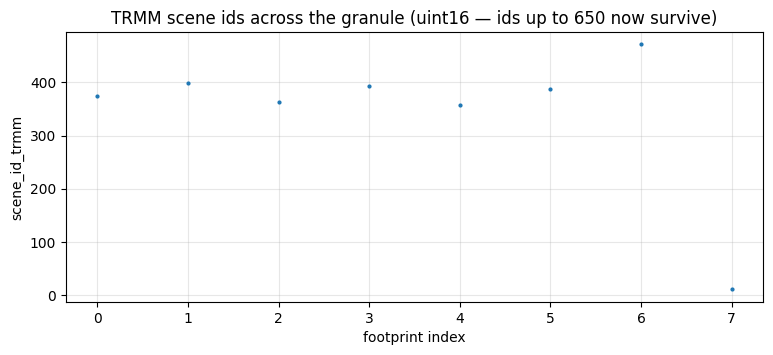

In [4]:
for name in scene_vars:
    var = product[name]
    ids = var.values[np.isfinite(var.values.astype(float))].astype(int)
    print(f"{name:18s} dtype={var.dtype}  distinct ids={len(np.unique(ids))}  max={ids.max() if ids.size else '-'}")

fig, ax = plt.subplots(figsize=(9, 3.5))
trmm = product["scene_id_trmm"].values.astype(float)
ax.plot(trmm, ".", ms=4)
ax.set_xlabel("footprint index")
ax.set_ylabel("scene_id_trmm")
ax.set_title("TRMM scene ids across the granule (uint16 — ids up to 650 now survive)")
ax.grid(alpha=0.3)
plt.show()
product.close()

## 3. IMAGER vs IMAGER-FLASH

The FLASH variant runs the identical classification on the low-latency
FMATCH-IMAGER-FLASH input (FLASHFlux-derived, PR 3): same code path, different
runner config and product identity — TRMM coverage is partial at that latency,
hence "partial TRMM" in its identifier.

In [5]:
from libera_utils.scene_identification.scene_id_imager_flash import (
    create_and_write_data_product_imager_flash,
    run_scene_identification_imager_flash,
)

flash_input = make_fmatch_product_fixture(workdir, OperationalMode.IMAGER_FLASH)
flash_output = create_and_write_data_product_imager_flash(
    run_scene_identification_imager_flash(flash_input), flash_input.name, workdir
)
with xr.open_dataset(flash_output.path) as flash_product:
    print(f"wrote {flash_output.path.name}")
    print(f"product attrs InputGranules: {flash_product.attrs['InputGranules']}")

wrote LIBERA_AUX_SCENE-ID-IMAGER-FLASH_V0-1-0_20260611T000000_20260611T000000_R26254174800.nc
product attrs InputGranules: LIBERA_AUX_FMATCH-IMAGER-FLASH_V0-1-0_20260611T000000_20260611T000000_R26254174800.nc


## 4. One package, four runners, one image

After this PR the `scene_identification` package is flat — the four runners share
`_runner.py` (manifest/dropbox plumbing) and a single Dockerfile, mirroring the
FMATCH layout:

In [6]:
import libera_utils.scene_identification as si

package_dir = Path(si.__file__).parent
for p in sorted(package_dir.glob("*")):
    if p.suffix == ".py" or p.name == "Dockerfile":
        print(p.name)

Dockerfile
__init__.py
_runner.py
scene_definitions.py
scene_id.py
scene_id_cam.py
scene_id_cam_camtime.py
scene_id_imager.py
scene_id_imager_flash.py


## The stack is complete

With this PR merged, the full chain runs end to end:

> L1B (radiometer / camera) → **FMATCH** (geometry → readers → tiles → PSF
> weighting → aggregation → product assembly → runners) → **Scene-ID**
> (CAM, CAM-CAMTIME, IMAGER, IMAGER-FLASH) → ADM selection downstream.

The FMATCH↔Scene-ID integration tests (`tests/integration/test_fmatch_runner.py`,
`test_scene_id_runner.py`) exercise that chain against the synthetic fixtures used
throughout these notebooks.